<a href="https://colab.research.google.com/github/Pete-Reseacher/python-geoscience/blob/main/Week_3_Reservoir_Quality_Trend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INTERPRETING RESERVOIR QUALITY TREND

## 4 STEP PROCESS
* VISUALIZING THE A TYPICAL WELL LOG PANEL
* STATISTICAL FACIES DISCRIMINATION
* RQI - RESERVOIR QUALITY TREND
* IDENTIFY NET PAY VS. NON-NET

## STEP 1


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import lasio as ls
import numpy as np

In [ ]:
las = ls.read("Well_A.las")
df = las.df().reset_index()
df.replace(las.well.NULL.value, np.nan, inplace=True)

In [ ]:
df

,DEPT,CALF,SON3,FDC,VSH,RT,POR,GR_NM
0,4901.0,NaN,NaN,1.5551,NaN,NaN,NaN,NaN
1,4901.5,NaN,NaN,1.5553,NaN,NaN,NaN,NaN
2,4902.0,NaN,NaN,1.5812,NaN,NaN,NaN,NaN
3,4902.5,NaN,NaN,1.6205,NaN,NaN,NaN,NaN
4,4903.0,NaN,NaN,1.6645,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
6176,7989.0,NaN,NaN,NaN,NaN,4.1563,NaN,NaN
6177,7989.5,NaN,NaN,NaN,NaN,4.1563,NaN,NaN
6178,7990.0,NaN,NaN,NaN,NaN,4.1564,NaN,NaN
6179,7990.5,NaN,NaN,NaN,NaN,4.1565,NaN,NaN


### Visualize the plots --> 1 panel (row), 3 plots (columns)

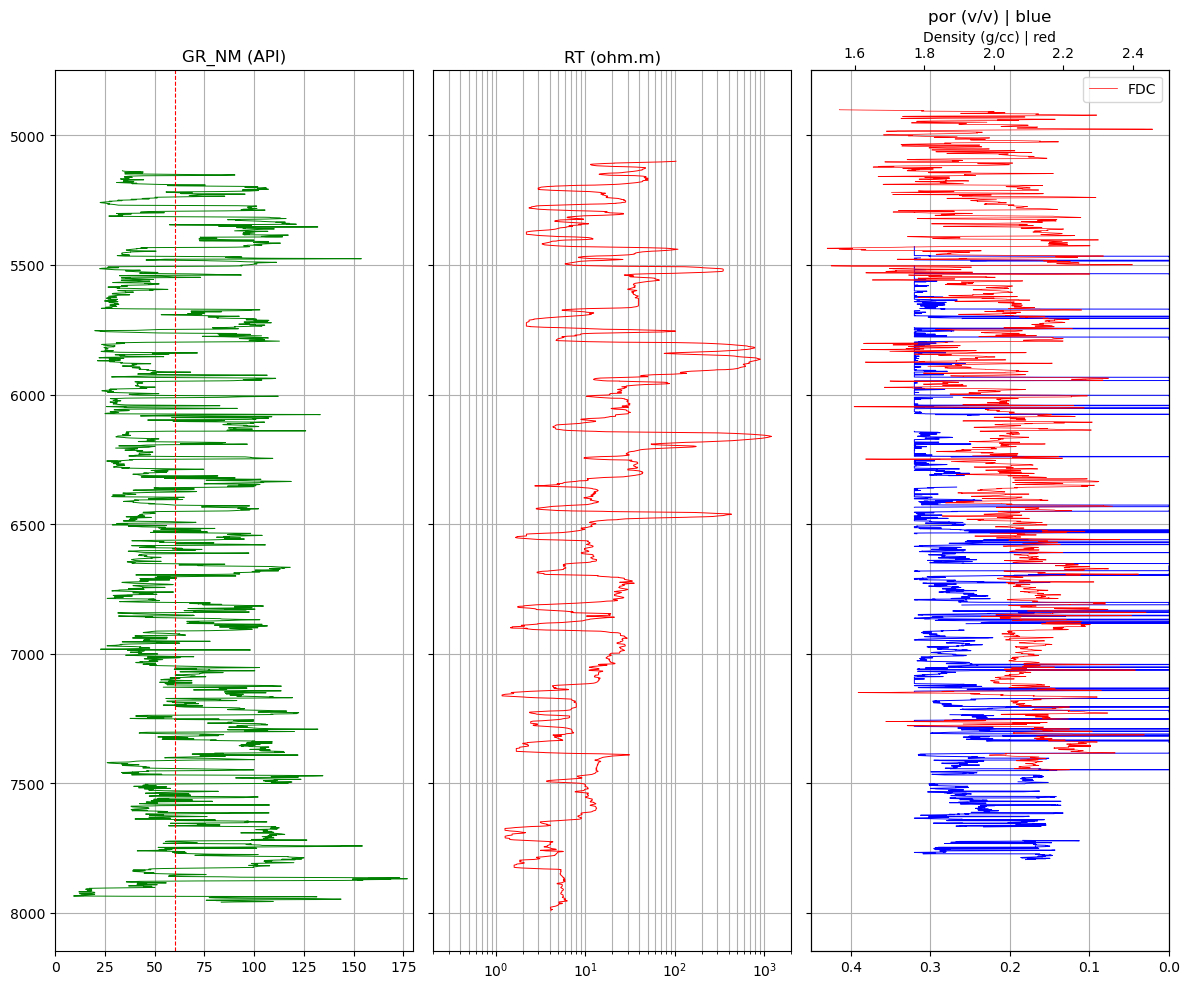

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12, 10), sharey=True)

# TRACK | GR
gr_cutoff = 60
ax[0].plot(df["GR_NM"], df["DEPT"], color="green", lw=0.7)
ax[0].axvline(x =gr_cutoff, color="red", ls="--", lw=0.8, label="gr_cutoff")
ax[0].set_title("GR_NM (API)")
ax[0].set_xlim(0, 180)
ax[0].grid(True)

# TRACK | RT
ax[1].plot(df["RT"], df["DEPT"], color="red", lw=0.7)
ax[1].set_xscale("log")
ax[1].set_title("RT (ohm.m)")
ax[1].set_xlim(0.2, 2000)
ax[1].grid(True, which="both")


# TRACK | POROSITY - DENSITY X-PLOT

ax[2].plot(df["POR"], df["DEPT"], color="blue", lw=0.7)
ax[2].set_title("por (v/v) | blue")
ax[2].set_xlim(0.45, 0)
ax[2].grid(True)

#Density plot

ax2_density = ax[2].twiny()
ax2_density.plot(df["FDC"], df["DEPT"], color="red", lw = 0.5, label ="FDC")
ax2_density.set_xlabel("Density (g/cc) | red")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.legend()


# STEP 2

### STATISTICAL FACIES DISCRIMINATION

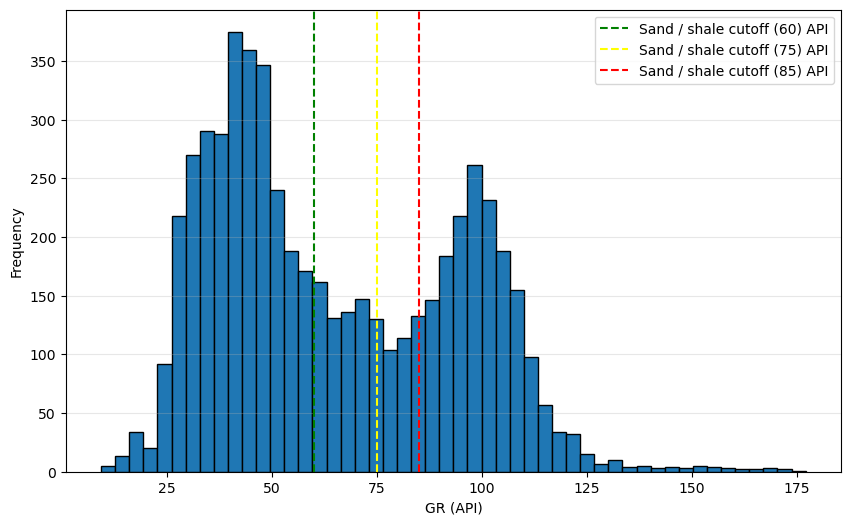

In [ ]:
plt.figure(figsize=(10,6))

#plot a histogram
gr_cutoff = 75
gr_cutoff_lowside = 60
gr_cutoff_highside = 85

plt.hist(df["GR_NM"], bins=50, edgecolor="black")

#vline

plt.axvline(gr_cutoff_lowside, color="green", ls ="--", label=f"Sand / shale cutoff ({gr_cutoff_lowside}) API")
plt.axvline(gr_cutoff, color="yellow", ls ="--", label=f"Sand / shale cutoff ({gr_cutoff}) API")
plt.axvline(gr_cutoff_highside, color="red", ls ="--", label=f"Sand / shale cutoff ({gr_cutoff_highside}) API")

plt.xlabel("GR (API)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)

plt.legend()

#p10, p50, p90

# STEP 3 - FEATURE ENGINEERING | RQI

#### NORMALIZED GR = (GR -  GR_MIN)/(GR_MAX - GR_MIN)

In [ ]:
gr_min = df["GR_NM"].min()
gr_max = df["GR_NM"].max()

df["GR_Norm"] = (df["GR_NM"] - gr_min)/(gr_max - gr_min)

# RQI = POROSITY * 1 - df["GR_Norm"]
df["RQI"] = df["POR"] * (1 - df["GR_Norm"])
df["RQI"].describe()

count    3842.000000
mean        0.194180
std         0.077771
min         0.000000
25%         0.166757
50%         0.212712
75%         0.251891
max         0.297144
Name: RQI, dtype: float64

Text(0.5, 1.0, 'RQI')

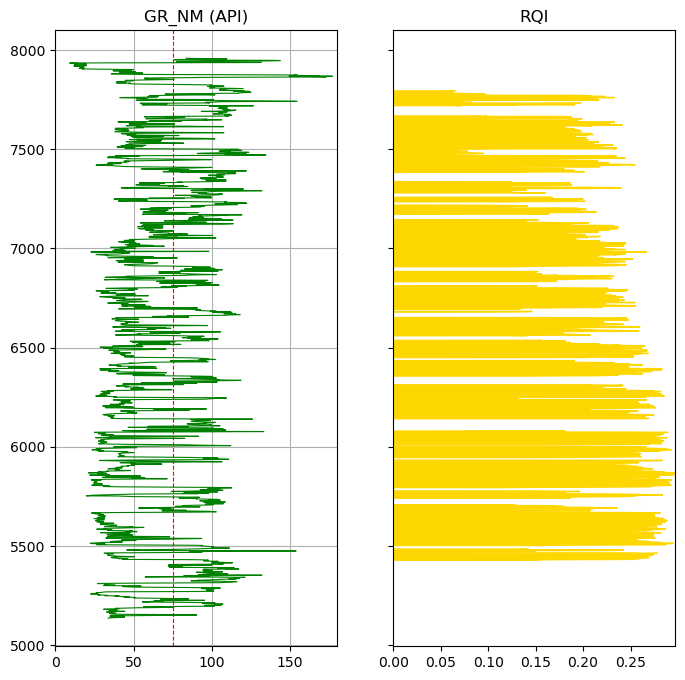

In [ ]:
fig, ax = plt.subplots(1, 2, figsize= (8,8), sharey=True)

ax[0].plot(df["GR_NM"], df["DEPT"], color="green", lw=0.8)
ax[0].axvline(x =gr_cutoff, color="red", ls="--", lw=0.8, label="gr_cutoff")
ax[0].set_title("GR_NM (API)")
ax[0].set_xlim(0, 180)
ax[0].grid(True)

#ax[1].plot(df["RQI"], df["DEPT"], color = "gold")
ax[1].fill_betweenx(df["DEPT"], 0, df["RQI"], color="gold")
ax[1].set_xlim(0, df["RQI"].max())
ax[1].set_title("RQI")


# STAGE 4

In [ ]:
gr_cutoff = 75
por_cutoff = 0.15

#Logic to create the Net pay
df["Is_Pay"] = (df["GR_NM"] <= gr_cutoff) & (df["POR"] >=por_cutoff)
df[df["Is_Pay"] == True][["GR_NM", "POR"]]

#Gross Thickness
# 0.5ft = 0.1524

sample_rate = 0.1524
net_pay_thickness = df["Is_Pay"].sum() * sample_rate
total_thickness =len(df) * sample_rate



# Final Reservoir


In [ ]:
print(f"--------RESERVOIR SUMMARY-------")
print(f"Total Thickness / Gross thickness: {total_thickness:.2f}")
print(f"The Net thickness is: {net_pay_thickness:.2f}")
print(f"NTG: {net_pay_thickness/total_thickness:.2%}")

--------RESERVOIR SUMMARY-------
Total Thickness / Gross thickness: 941.98
The Net thickness is: 446.99
NTG: 47.45%
